# Hands-on: Estatística Avançada, Detecção de Anomalias e Auditoria Ética
**Objetivo:** Aplicar métodos estatísticos robustos para diagnosticar a saúde de um dataset clínico e auditar possíveis vieses demográficos que poderiam comprometer a justiça (fairness) de um futuro modelo preditivo.

**Dataset:** Heart Disease (Cleveland) - UCI Machine Learning Repository.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Configuração visual padrão para gráficos acadêmicos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Ambiente configurado com sucesso.")

Ambiente configurado com sucesso.


## 1. Coleta e Exploração Inicial (EDA)
Vamos carregar os dados. Um detalhe técnico e ético: este dataset possui valores ausentes marcados como `?`. Como lidamos com dados nulos em saúde? Preencher com a média pode mascarar patologias reais.

In [2]:
# Carregamento direto do repositório da UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Dicionário de colunas baseado na documentação oficial
colunas = [
    'idade', 'sexo', 'tipo_dor_peito', 'pressao_repouso',
    'colesterol', 'glicemia_jejum', 'ecg_repouso', 'freq_cardiaca_max',
    'angina_exercicio', 'depressao_st', 'inclinacao_st',
    'num_vasos_coloridos', 'talassemia', 'diagnostico'
]

# Lendo o arquivo e convertendo '?' para NaN (Not a Number) nativo do Pandas
df = pd.read_csv(url, names=colunas, na_values='?')

print(f"Dimensões do Dataset: {df.shape[0]} pacientes e {df.shape[1]} atributos clínicos.")

# Verificando dados nulos (Falta de dados sensíveis)
print("\nValores Nulos Detectados:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Decisão Técnica: Como a quantidade de nulos é baixa (menos de 2%), optaremos pela exclusão
# para não introduzir vieses artificiais de imputação em exames críticos como 'talassemia'.
df = df.dropna()

Dimensões do Dataset: 303 pacientes e 14 atributos clínicos.

Valores Nulos Detectados:
num_vasos_coloridos    4
talassemia             2
dtype: int64


In [3]:
df.describe()

,idade,sexo,tipo_dor_peito,pressao_repouso,colesterol,glicemia_jejum,ecg_repouso,freq_cardiaca_max,angina_exercicio,depressao_st,inclinacao_st,num_vasos_coloridos,talassemia,diagnostico
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,4.730640,0.946128
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,1.938629,1.234551
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   idade                297 non-null    float64
 1   sexo                 297 non-null    float64
 2   tipo_dor_peito       297 non-null    float64
 3   pressao_repouso      297 non-null    float64
 4   colesterol           297 non-null    float64
 5   glicemia_jejum       297 non-null    float64
 6   ecg_repouso          297 non-null    float64
 7   freq_cardiaca_max    297 non-null    float64
 8   angina_exercicio     297 non-null    float64
 9   depressao_st         297 non-null    float64
 10  inclinacao_st        297 non-null    float64
 11  num_vasos_coloridos  297 non-null    float64
 12  talassemia           297 non-null    float64
 13  diagnostico          297 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 34.8 KB


## 2. Estatística Descritiva, Assimetria (Skewness) e Curtose (Kurtosis)
A média é perigosa em dados de saúde. Vamos comparar a Média com a Mediana e calcular os índices de Assimetria e Curtose para entender o risco de eventos extremos (caudas pesadas).

,Média,Mediana,Desvio Padrão,Assimetria (Skewness),Curtose (Kurtosis)
idade,54.542088,56.0,9.049736,-0.219775,-0.521754
pressao_repouso,131.693603,130.0,17.762806,0.700070,0.814982
colesterol,247.350168,243.0,51.997583,1.118096,4.444077
freq_cardiaca_max,149.599327,153.0,22.941562,-0.536540,-0.051849


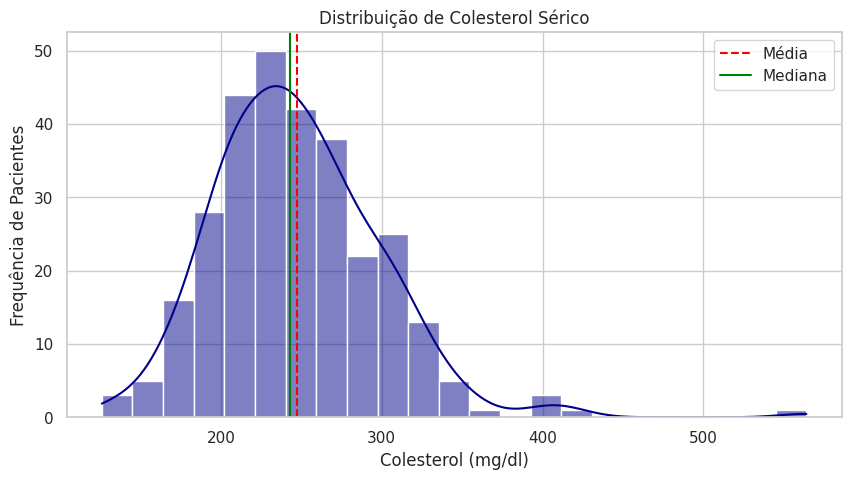

In [ ]:
# Variáveis clínicas contínuas
vars_continuas = ['idade', 'pressao_repouso', 'colesterol', 'freq_cardiaca_max']

# Criando um DataFrame comparativo
analise_dist = pd.DataFrame({
    'Média': df[vars_continuas].mean(),
    'Mediana': df[vars_continuas].median(),
    'Desvio Padrão': df[vars_continuas].std(),
    'Assimetria (Skewness)': df[vars_continuas].skew(),
    'Curtose (Kurtosis)': df[vars_continuas].kurt()
})

display(analise_dist)

# Visualizando a assimetria do Colesterol
plt.figure(figsize=(10, 5))
sns.histplot(df['colesterol'], kde=True, color='darkblue')
plt.title('Distribuição de Colesterol Sérico')
plt.xlabel('Colesterol (mg/dl)')
plt.ylabel('Frequência de Pacientes')
plt.axvline(df['colesterol'].mean(), color='red', linestyle='--', label='Média')
plt.axvline(df['colesterol'].median(), color='green', linestyle='-', label='Mediana')
plt.legend()
plt.show()

## 3. Correlação de Pearson e Proxies Discriminatórios
O Heatmap revela redundâncias, mas exige cuidado ético: uma variável técnica pode estar altamente correlacionada a uma variável demográfica (Proxy), transferindo o viés histórico para o algoritmo.

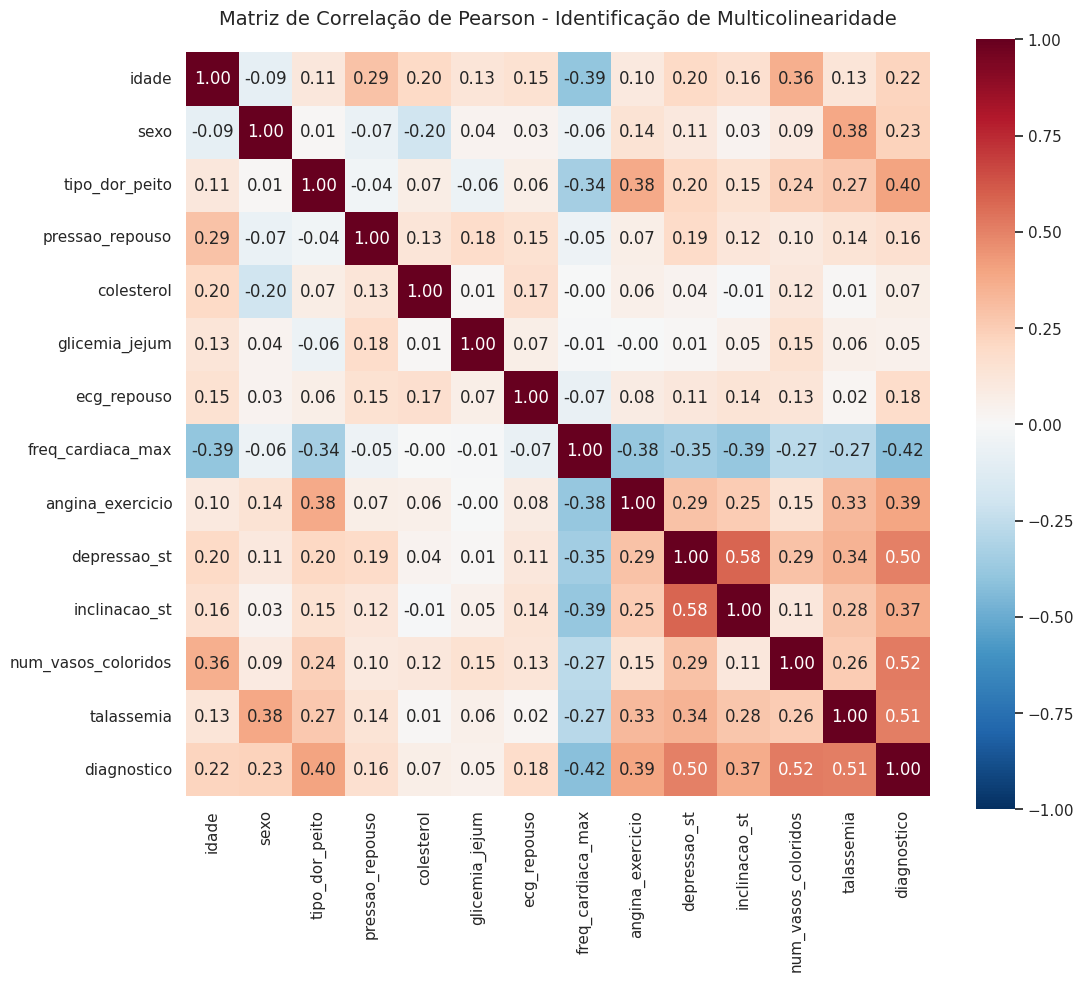

In [ ]:
# Calculando a matriz de correlação (Apenas colunas numéricas)
matriz_corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap='RdBu_r', vmin=-1, vmax=1, square=True)
plt.title('Matriz de Correlação de Pearson - Identificação de Multicolinearidade', fontsize=14, pad=20)
plt.show()

## 4. Detecção Matemática de Anomalias (Z-Score e IQR)
Vamos programar os dois filtros estatísticos abordados na aula teórica para a variável `colesterol`.

**O Dilema do Engenheiro:** O código abaixo isolará os "Outliers". Antes de aplicar um `.drop()`, reflita: excluir esses pacientes melhora a curva matemática, mas apaga o histórico das pessoas em estado mais crítico.

Anomalias isoladas pelo Z-Score (Z > 3): 4 pacientes.
Anomalias isoladas pelo IQR (Robustez): 5 pacientes.



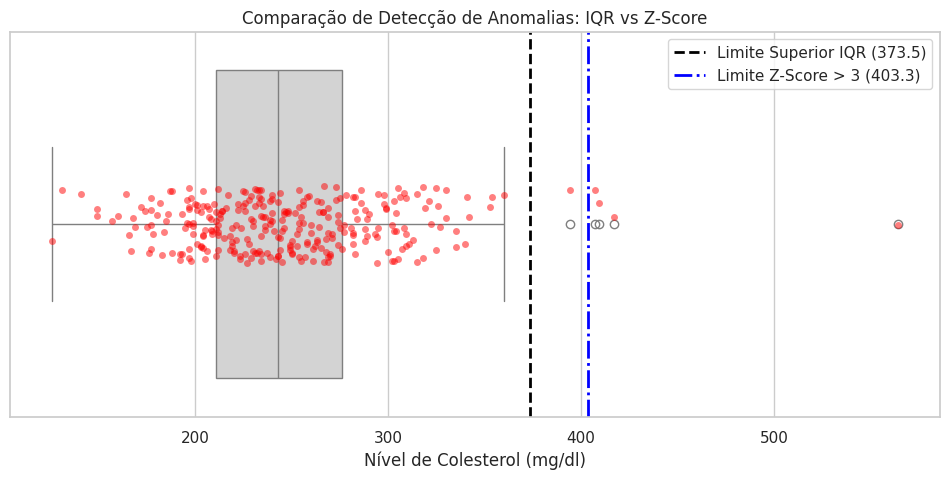

In [4]:
# Definindo a coluna alvo para a análise
alvo = 'colesterol'

# --- Método 1: Z-Score (Distância em Desvios Padrões) ---
media = df[alvo].mean()
std = df[alvo].std()
df['z_score'] = np.abs((df[alvo] - media) / std)

# Pacientes com Z-Score > 3
outliers_z = df[df['z_score'] > 3]

# --- Método 2: IQR (Intervalo Interquartil - Robusto a assimetria) ---
Q1 = df[alvo].quantile(0.25)
Q3 = df[alvo].quantile(0.75)
IQR = Q3 - Q1
limite_sup = Q3 + 1.5 * IQR

outliers_iqr = df[df[alvo] > limite_sup]

print(f"Anomalias isoladas pelo Z-Score (Z > 3): {len(outliers_z)} pacientes.")
print(f"Anomalias isoladas pelo IQR (Robustez): {len(outliers_iqr)} pacientes.\n")

#BPLOT
plt.figure(figsize=(12, 5))

# Desenha o Boxplot e os pontos dos pacientes
sns.boxplot(x=df[alvo], color='lightgray')
sns.stripplot(x=df[alvo], color='red', alpha=0.5, jitter=True)

# 1. Linha do Limite IQR (Robusto)
plt.axvline(limite_sup, color='black', linestyle='--', linewidth=2,
            label=f'Limite Superior IQR ({limite_sup:.1f})')

# 2. Linha do Limite Z-Score (Paramétrico)
limite_zscore = media + (3 * std)
plt.axvline(limite_zscore, color='blue', linestyle='-.', linewidth=2,
            label=f'Limite Z-Score > 3 ({limite_zscore:.1f})')

plt.title('Comparação de Detecção de Anomalias: IQR vs Z-Score')
plt.xlabel('Nível de Colesterol (mg/dl)')
plt.legend()
plt.show()

## 5. Auditoria Ética: Métricas de Fairness (Justiça Demográfica)
Como vimos na teoria (Bloco 1), algoritmos replicam injustiças históricas. Vamos auditar a **Paridade Demográfica** em nossos dados em relação à variável `sexo` (onde 1 = Masculino, 0 = Feminino, segundo a documentação da UCI).

Vamos investigar: O diagnóstico positivo de doença cardíaca (> 0) está distribuído de forma justa entre homens e mulheres neste conjunto de dados de treinamento?

Contagem genero
Masculino    201
Feminino      96
Name: count, dtype: int64
Contagem de doentes por sexo genero
Masculino    112
Feminino      25
Name: count, dtype: int64
--- Auditoria de Paridade Demográfica (Historical Data) ---
Taxa de diagnóstico positivo em Mulheres: 26.04%
Taxa de diagnóstico positivo em Homens: 55.72%


/tmp/ipykernel_2655/2633218160.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=taxa_diagnostico.index, y=taxa_diagnostico.values, palette='viridis')


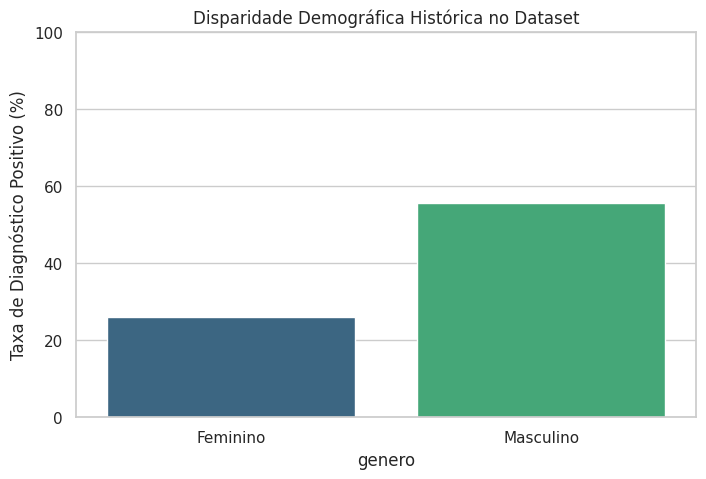

In [8]:
# Binarizando o diagnóstico (0 = saudável, >0 = presença de doença cardíaca)
df['doenca_cardiaca'] = df['diagnostico'].apply(lambda x: 1 if x > 0 else 0)

# Mapeando o sexo para legibilidade (Conforme dicionário da UCI)
df['genero'] = df['sexo'].map({1.0: 'Masculino', 0.0: 'Feminino'})

print("Contagem", df['genero'].value_counts())
print("Contagem de doentes por sexo", df['genero'].where(df['doenca_cardiaca'] == 1).value_counts())

# Calculando a taxa de diagnóstico positivo por gênero (Demographic Parity)
taxa_diagnostico = df.groupby('genero')['doenca_cardiaca'].mean() * 100

print("--- Auditoria de Paridade Demográfica (Historical Data) ---")
print(f"Taxa de diagnóstico positivo em Mulheres: {taxa_diagnostico['Feminino']:.2f}%")
print(f"Taxa de diagnóstico positivo em Homens: {taxa_diagnostico['Masculino']:.2f}%")

# Gráfico para Evidenciar o Viés de Representação
plt.figure(figsize=(8, 5))
sns.barplot(x=taxa_diagnostico.index, y=taxa_diagnostico.values, palette='viridis')
plt.title('Disparidade Demográfica Histórica no Dataset')
plt.ylabel('Taxa de Diagnóstico Positivo (%)')
plt.ylim(0, 100)
plt.show()

### Discussão Final
Os dados acima mostram uma disparidade massiva entre os gêneros neste dataset específico da década de 1980 em Cleveland.
**Se treinarmos uma Inteligência Artificial sem balancear ou corrigir esse viés estatístico**, o modelo estatisticamente associará o simples fato de "ser mulher" a uma menor probabilidade de doença cardíaca, o que pode atrasar diagnósticos vitais em hospitais reais hoje.

Isso consolida a lição de hoje: **A Estatística detecta a assimetria, mas é a sua Ética que impede que a assimetria se transforme em uma "arma automatizada".**